In [1]:
# Step 1: Load dataset and remove unnecessary columns 

import pandas as pd

# Load dataset
df = pd.read_csv("D:\Infosys_Springboard\CreditPathAI\CreditPathAI\data\Loan_Default.csv")
df.head()
df1 = df.drop(['ID', 'year'], axis=1)
df1.head()



<>:6: SyntaxWarning: invalid escape sequence '\I'
<>:6: SyntaxWarning: invalid escape sequence '\I'
C:\Users\srila\AppData\Local\Temp\ipykernel_23708\863313222.py:6: SyntaxWarning: invalid escape sequence '\I'
  df = pd.read_csv("D:\Infosys_Springboard\CreditPathAI\CreditPathAI\data\Loan_Default.csv")


,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [2]:
df1.head()


,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [3]:
from sklearn.impute import SimpleImputer
num_cols = df1.select_dtypes(include=['int64', 'float64']).columns

mean_imputer = SimpleImputer(strategy='mean')
df1[num_cols] = mean_imputer.fit_transform(df1[num_cols])

print("Missing values after mean imputation:\n", df1[num_cols].isnull().sum())

Missing values after mean imputation:
 loan_amount             0
rate_of_interest        0
Interest_rate_spread    0
Upfront_charges         0
term                    0
property_value          0
income                  0
Credit_Score            0
LTV                     0
Status                  0
dtir1                   0
dtype: int64


In [13]:
num_cols = df1.select_dtypes(include=['int64', 'float64']).columns

median_imputer = SimpleImputer(strategy='median')
df1[num_cols] = median_imputer.fit_transform(df1[num_cols])

print("Missing values after median imputation:\n", df1[num_cols].isnull().sum())

Missing values after median imputation:
 loan_amount             0
rate_of_interest        0
Interest_rate_spread    0
Upfront_charges         0
term                    0
property_value          0
income                  0
Credit_Score            0
LTV                     0
Status                  0
dtir1                   0
dtype: int64


In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer


num_cols = df1.select_dtypes(include=['int64', 'float64']).columns

knn_imputer = KNNImputer(n_neighbors=5)
df1[num_cols] = knn_imputer.fit_transform(df1[num_cols])

print("Missing values after KNN imputation:\n", df1[num_cols].isnull().sum())


In [17]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


num_cols = df1.select_dtypes(include=['int64', 'float64']).columns

iterative_imputer = IterativeImputer(random_state=42)
df1[num_cols] = iterative_imputer.fit_transform(df1[num_cols])

print("Missing values after Iterative imputation:\n", df1[num_cols].isnull().sum())


Missing values after Iterative imputation:
 ID                      0
year                    0
loan_amount             0
rate_of_interest        0
Interest_rate_spread    0
Upfront_charges         0
term                    0
property_value          0
income                  0
Credit_Score            0
LTV                     0
Status                  0
dtir1                   0
dtype: int64


In [4]:
cat_cols = df1.select_dtypes(include=['object']).columns

mode_imputer = SimpleImputer(strategy='most_frequent')
df1[cat_cols] = mode_imputer.fit_transform(df1[cat_cols])


print("Missing values after mode imputation:\n", df1[cat_cols].isnull().sum())


Missing values after mode imputation:
 loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
credit_type                  0
co-applicant_credit_type     0
age                          0
submission_of_application    0
Region                       0
Security_Type                0
dtype: int64


In [5]:
cat_cols = df1.select_dtypes(include=['object']).columns
print("Categorical columns:", list(cat_cols))

Categorical columns: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']


One-Hot Encoding
Pros: Simple, works well with tree-based and linear models.

Cons: Can increase dimensionality if many categories.

In [6]:
df1 = pd.get_dummies(df1, columns=cat_cols, drop_first=True)

print(df1.head())

   loan_amount  rate_of_interest  Interest_rate_spread  Upfront_charges  \
0     116500.0          4.045476              0.441656      3224.996127   
1     206500.0          4.045476              0.441656      3224.996127   
2     406500.0          4.560000              0.200000       595.000000   
3     456500.0          4.250000              0.681000      3224.996127   
4     696500.0          4.000000              0.304200         0.000000   

    term  property_value   income  Credit_Score        LTV  Status  ...  \
0  360.0   118000.000000   1740.0         758.0  98.728814     1.0  ...   
1  360.0   497893.465696   4980.0         552.0  72.746457     1.0  ...   
2  360.0   508000.000000   9480.0         834.0  80.019685     0.0  ...   
3  360.0   658000.000000  11880.0         587.0  69.376900     0.0  ...   
4  360.0   758000.000000  10440.0         602.0  91.886544     0.0  ...   

   age_45-54  age_55-64  age_65-74  age_<25  age_>74  \
0      False      False      False    Fals

Label Encoding (Not for nominal, but works for ordinal)
Pros: Converts categories to integers.

Cons: Imposes order which may confuse models for nominal features.

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df1[col] = le.fit_transform(df1[col])  # assign back to the column

print(df1.head())


   loan_limit  Gender  approv_in_adv  loan_type  loan_purpose  \
0           0       3              0          0             0   
1           0       2              0          1             0   
2           0       2              1          0             0   
3           0       2              0          0             3   
4           0       1              1          0             0   

   Credit_Worthiness  open_credit  business_or_commercial  loan_amount  \
0                  0            0                       1     116500.0   
1                  0            0                       0     206500.0   
2                  0            0                       1     406500.0   
3                  0            0                       1     456500.0   
4                  0            0                       1     696500.0   

   rate_of_interest  ...  credit_type  Credit_Score  co-applicant_credit_type  \
0              3.99  ...            3         758.0                         0   
1 

In [7]:
# Separate features (X) and target (y)
X = df1.drop('Status', axis=1)
y = df1['Status']

print("\nFeatures (X) shape:", X.shape)
print("Target (y) shape:", y.shape)


Features (X) shape: (148670, 48)
Target (y) shape: (148670,)


In [8]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (118936, 48)
Testing set shape: (29734, 48)


In [9]:
df1.isnull().sum()

loan_amount                          0
rate_of_interest                     0
Interest_rate_spread                 0
Upfront_charges                      0
term                                 0
property_value                       0
income                               0
Credit_Score                         0
LTV                                  0
Status                               0
dtir1                                0
loan_limit_ncf                       0
Gender_Joint                         0
Gender_Male                          0
Gender_Sex Not Available             0
approv_in_adv_pre                    0
loan_type_type2                      0
loan_type_type3                      0
loan_purpose_p2                      0
loan_purpose_p3                      0
loan_purpose_p4                      0
Credit_Worthiness_l2                 0
open_credit_opc                      0
business_or_commercial_nob/c         0
Neg_ammortization_not_neg            0
interest_only_not_int    

In [10]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [31]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

StandardScaler (Z-score normalization)

Scales features to mean = 0, standard deviation = 1.

Good for most ML algorithms, especially those sensitive to magnitude (Logistic Regression, SVM, KNN).

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)  # After SMOTE
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_res.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train_res.columns)

print("StandardScaler applied.")


StandardScaler applied.


MinMaxScaler (0-1 scaling)

Scales features to a fixed range [0,1].

Useful when features are bounded and you want all in same range.

In [21]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_res.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train_res.columns)

print("MinMaxScaler applied.")


MinMaxScaler applied.


RobustScaler

Scales features using median and IQR (interquartile range).

Good for data with outliers, as it is robust to them.

In [12]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_res)  # After SMOTE
X_test_scaled = scaler.transform(X_test)

print("RobustScaler applied. Features are now scaled and ready for modeling.")


RobustScaler applied. Features are now scaled and ready for modeling.


In [13]:
print(X_test_scaled.shape)
print(y_test.shape)


(29734, 48)
(29734,)


In [34]:
# Convert to numpy and ensure integer labels
X_train_scaled = X_train_scaled.astype(float)   # already fine if scaled
y_train_res = y_train_res.astype(int).values    # convert to numpy array of ints


--- Training Logistic Regression ---


d:\Infosys_Springboard\CreditPathAI\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression trained successfully.

--- Training Random Forest ---
Random Forest trained successfully.

--- Training XGBoost ---


d:\Infosys_Springboard\CreditPathAI\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:02:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained successfully.

--- Training KNN ---
KNN trained successfully.

--- Training Decision Tree ---
Decision Tree trained successfully.

--- Training Naive Bayes ---
Naive Bayes trained successfully.

--- Training Gradient Boosting ---
Gradient Boosting trained successfully.

--- Training LightGBM ---
[LightGBM] [Info] Number of positive: 89625, number of negative: 89625
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017388 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2574
[LightGBM] [Info] Number of data points in the train set: 179250, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

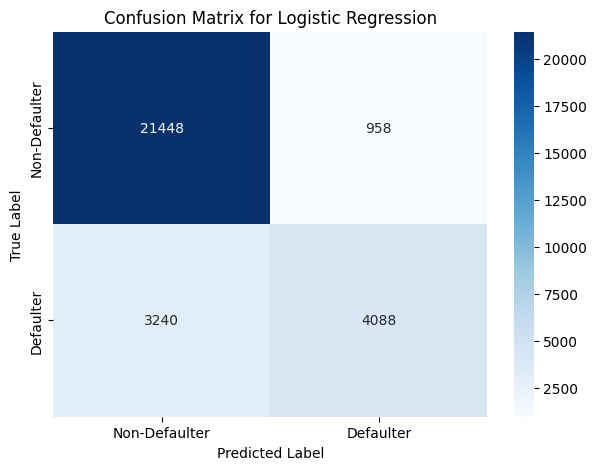


--- Evaluation for Random Forest ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734

ROC-AUC Score: 1.0000


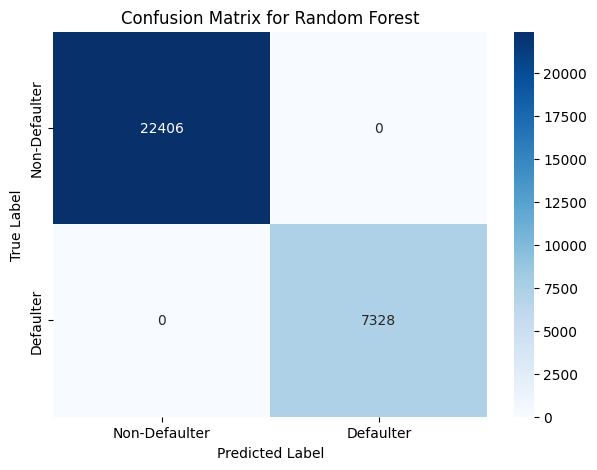


--- Evaluation for XGBoost ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734

ROC-AUC Score: 1.0000


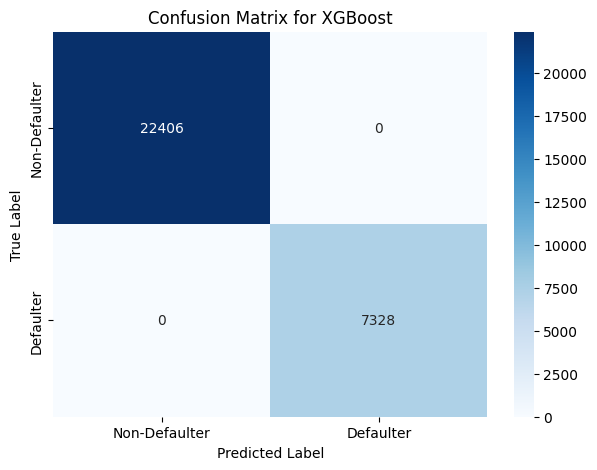


--- Evaluation for KNN ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     22406
           1       0.97      1.00      0.99      7328

    accuracy                           0.99     29734
   macro avg       0.99      0.99      0.99     29734
weighted avg       0.99      0.99      0.99     29734

ROC-AUC Score: 0.9979


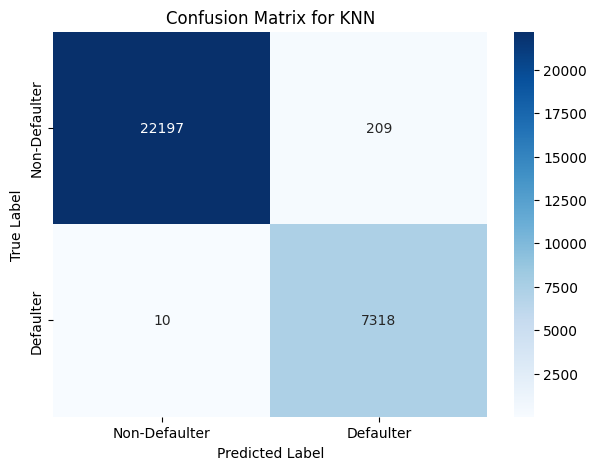


--- Evaluation for Decision Tree ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734

ROC-AUC Score: 1.0000


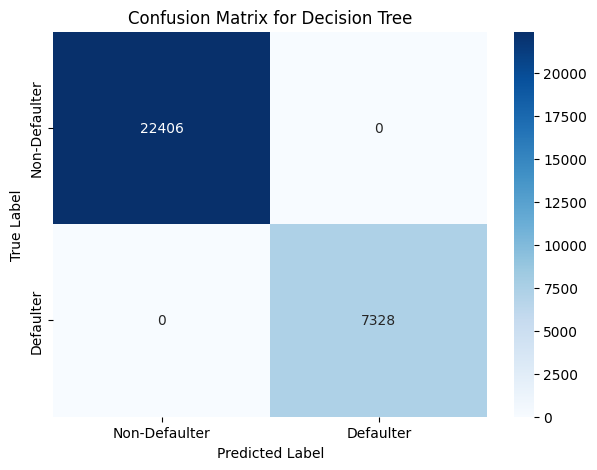


--- Evaluation for Naive Bayes ---
Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     22406
           1       1.00      0.66      0.80      7328

    accuracy                           0.92     29734
   macro avg       0.95      0.83      0.87     29734
weighted avg       0.93      0.92      0.91     29734

ROC-AUC Score: 1.0000


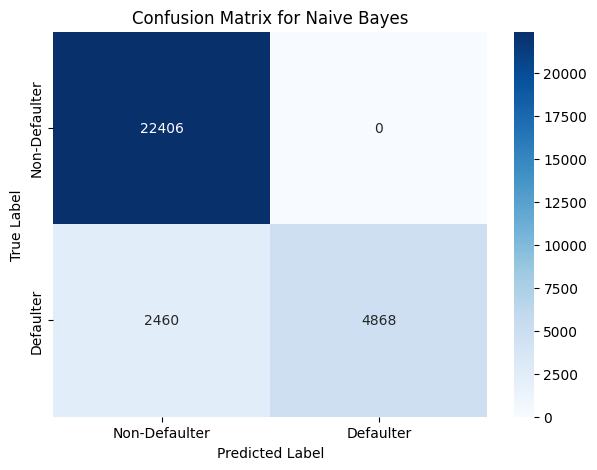


--- Evaluation for Gradient Boosting ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734

ROC-AUC Score: 1.0000


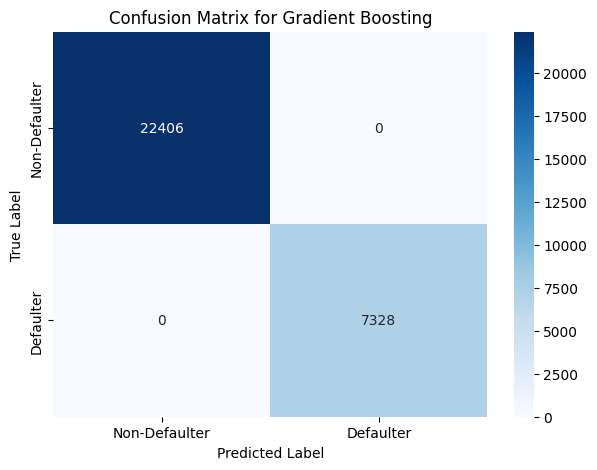


--- Evaluation for LightGBM ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734

ROC-AUC Score: 1.0000


d:\Infosys_Springboard\CreditPathAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Infosys_Springboard\CreditPathAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


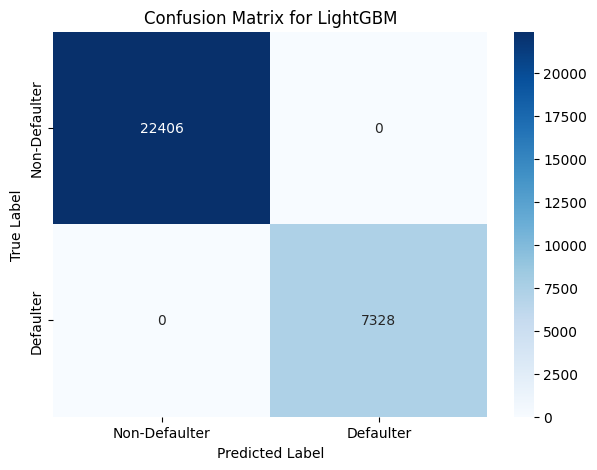


--- Evaluation for CatBoost ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22406
           1       1.00      1.00      1.00      7328

    accuracy                           1.00     29734
   macro avg       1.00      1.00      1.00     29734
weighted avg       1.00      1.00      1.00     29734

ROC-AUC Score: 1.0000


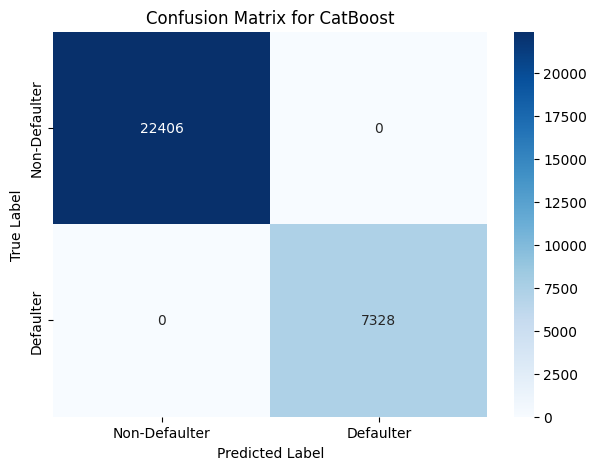



Final Results Summary:
+----+---------------------+------------+-------------------------+----------------------+------------------------+----------+
|    | Model               |   Accuracy |   Precision (Defaulter) |   Recall (Defaulter) |   F1-score (Defaulter) |      AUC |
+====+=====================+============+=========================+======================+========================+==========+
|  0 | Logistic Regression |   0.858815 |                0.810147 |             0.55786  |               0.66074  | 0.821404 |
+----+---------------------+------------+-------------------------+----------------------+------------------------+----------+
|  1 | Random Forest       |   1        |                1        |             1        |               1        | 1        |
+----+---------------------+------------+-------------------------+----------------------+------------------------+----------+
|  2 | XGBoost             |   1        |                1        |             1     

In [14]:
# ---------------------------
# Step 0: Import libraries
# ---------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tabulate import tabulate

# ---------------------------
# Step 1: Initialize models
# ---------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, random_state=42, eval_metric="logloss"),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
}

# ---------------------------
# Step 2: Ensure data format is safe
# ---------------------------
# Convert scaled features to NumPy arrays (avoids XGBoost/LightGBM feature name issues)
if hasattr(X_train_scaled, "values"):
    X_train_scaled = X_train_scaled.values
    X_test_scaled = X_test_scaled.values

# Ensure labels are integers in NumPy arrays
y_train_res = np.array(y_train_res).astype(int)
y_test = np.array(y_test).astype(int)

# ---------------------------
# Step 3: Train models
# ---------------------------
for name, model in models.items():
    print(f"--- Training {name} ---")
    model.fit(X_train_scaled, y_train_res)
    print(f"{name} trained successfully.\n")

# ---------------------------
# Step 4: Evaluate models + Collect Results
# ---------------------------
results = []

for name, model in models.items():
    print(f"\n--- Evaluation for {name} ---")

    # Predict on test set
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # ROC-AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"ROC-AUC Score: {auc_score:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Defaulter', 'Defaulter'],
                yticklabels=['Non-Defaulter', 'Defaulter'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Collect results
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision (Defaulter)": report["1"]["precision"],
        "Recall (Defaulter)": report["1"]["recall"],
        "F1-score (Defaulter)": report["1"]["f1-score"],
        "AUC": auc_score
    })

# ---------------------------
# Step 5: Summary Table
# ---------------------------
results_df = pd.DataFrame(results)
print("\n\nFinal Results Summary:")
print(tabulate(results_df, headers="keys", tablefmt="grid"))

